# Machine Learning - ARX Model

$$y(k) + a_1y(k-1) + \dots + a_ny(k-n) = b_0u(k-d)+ \dots + b_mu(k-d-m) + e(k)$$

Where 

$\bullet$ $k$ : discrete time $[0,N-1]$

$\bullet$ $y$ : output sequence

$\bullet$  $u \in R^{N}$ : input sequence 

$\bullet $   $e$ : noise sequence

$\bullet $   $n\geq 0, m\geq 0, d\geq 0$ : model order parameters.

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split   

## Data importation

In [100]:
# Data importation
u_test = np.load('u_test.npy')
u_train = np.load('u_train.npy')
output_train = np.load('output_train.npy')

The problem can be formulated as a linear regression :

$$y(k) = \phi(k)^{T}\theta + e(k)$$

where 

$$\phi(k) = [y(k-1),\dots,y(k-n),u(k-d),\dots,u(k-d-m)]^{T}$$

and 

$$ \theta = [-a_1,\dots,-a_n,b_0,\dots,b_m]$$

The systeme is initially at rest $(y(k) = 0, \forall k < 0)$

In [101]:
# Size of the data
print('Size of the training data:', u_train.shape)
print('Size of the testing data:', u_test.shape)
print('Size of the output data:', output_train.shape)

Size of the training data: (2040,)
Size of the testing data: (510,)
Size of the output data: (2040,)


**For given $n$, $m$ and $d$ and a sequence of input-output the model is rewritten in matrix form** :

$$Y = X\theta$$

$Y = [y(p),\dots,y(N-1)]^{T}$, $X = [\phi(p),\dots,\phi(N-1)]^{T}$, $p = max(n,d+m)$

We assume that $n<10$, $m<10$, $d<10$.

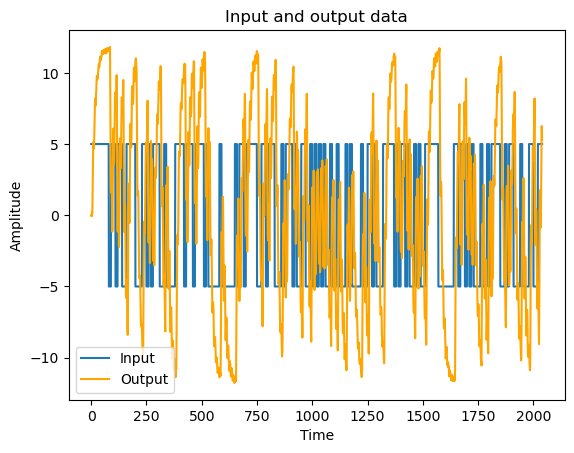

In [102]:
plt.plot(range(0,u_train.shape[0]), u_train,label='Input')
plt.plot(range(0,u_train.shape[0]), output_train, label='Output',color='orange')
plt.legend()
plt.title('Input and output data')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

## Functions definitions

### Function $\phi$ 

In [103]:
# phi function
def phi(k,n,d,m,u_input,y_output):
    """u_input: input data
       y_output: output data
       p: time
       phi(p) = [y(p-1),y(p-2),...,y(p-n),u(p-d),u(p-d-1),...,u(p-d-m)]
    """

    if k==0:

        return np.array([0,u_input[0]])
    
    else:

        # first part of the vector for y(k-1) to y(k-n)
        if n==0:
            first_part = np.zeros(1)
            first_part[0] = y_output[0]
        else:
            first_part = np.zeros(n)

        for i in range(1,n+1):
            #if k-i :
                #first_part
            first_part[i-1] = y_output[k-i]
            #first_part[i-1] = k-i
        # second part of the vector for u(k-d) to u(k-d-m)

        second_part = np.zeros(m+1)
        for i in range(d,d+m+1):
            
            second_part[i-d] = u_input[k-i]
            
            #second_part[i-d] = k-i

        # concatenation of the two parts
        phi = np.concatenate((first_part,second_part))
        #print('Size of phi:', phi.shape, "the size of n+m+1 is :", n+m+1)

    return phi

print(phi(1,1,0,0,u_train,output_train))
print(phi(1,0,1,0,u_train,output_train))
print(phi(1,0,0,1,u_train,output_train))
print(phi(0,0,0,0,u_train,output_train))

[-0.02047077  5.        ]
[-0.02047077  5.        ]
[-0.02047077  5.          5.        ]
[0. 5.]


In [104]:
output_train[0]

-0.020470765948471296

### Function $y(k)$

In [105]:
def y(k,n,d,m,u_input,y_output,theta, noise) :
    """
    y(k) = phi(k)*theta + noise
    """
    return np.multiply(phi(k,n,d,m,u_input,y_output),theta) + noise

### Parameter P 

In [106]:
def p_calculation(n,d,m):
    return np.max(n,d+m)

## Creation of the DataFrame

We are going to create a DataFrame where we can store the combination of paremeters used to create each "feature" matrix and the resulting SSE of the respective model    

In [107]:
# Crecreation of parameters 
n_seq = range(10)
d_seq = range(10)
m_seq = range(10)

# Creation of a suppor array
m_zeros = np.zeros((np.size(n_seq)*np.size(d_seq)*np.size(m_seq),5))

# Columns names
c_names = ['n','d','m','p','SSE']

# Creation of the DataFrame
df_results = pd.DataFrame(data = m_zeros, columns = c_names) 

df_results.head()

,n,d,m,p,SSE
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [142]:
def X_creation(p,n,d,m,u_input,y_output) :

    X = np.zeros([u_input.shape[0]-1-p,n+m+1])
    print(p)
    if p == 1:

        if (n==0) | (d==1):

            X = np.zeros([u_input.shape[0]-1-p,2])

        if m==1 :

            X = np.zeros([u_input.shape[0]-1-p,3])

    else :
        X = np.zeros([u_input.shape[0]-1-p,2])
    
   

    for k in range(p,u_input.shape[0]-1) :
        phi_k = phi(k,n,d,m,u_input,y_output)
        X[k-p,:] = phi_k
        
    return X

print(X_creation(1,1,0,0,u_train,output_train))
print(X_creation(1,0,1,0,u_train,output_train))
print(X_creation(1,0,0,1,u_train,output_train))
print(X_creation(0,0,0,0,u_train,output_train))

1
[[-0.02047077  5.        ]
 [ 0.04789433  5.        ]
 [-0.05194387  5.        ]
 ...
 [ 2.83921742  5.        ]
 [ 5.06508197  5.        ]
 [ 6.25651479  5.        ]]
1
[[-0.02047077  5.        ]
 [-0.02047077  5.        ]
 [-0.02047077  5.        ]
 ...
 [-0.02047077  5.        ]
 [-0.02047077  5.        ]
 [-0.02047077  5.        ]]
1
[[-0.02047077  5.          5.        ]
 [-0.02047077  5.          5.        ]
 [-0.02047077  5.          5.        ]
 ...
 [-0.02047077  5.          5.        ]
 [-0.02047077  5.          5.        ]
 [-0.02047077  5.          5.        ]]
0
[[ 0.          5.        ]
 [-0.02047077  5.        ]
 [-0.02047077  5.        ]
 ...
 [-0.02047077  5.        ]
 [-0.02047077  5.        ]
 [-0.02047077  5.        ]]


In [143]:
lr = LinearRegression()

cont = 0

for n in n_seq:
    for d in d_seq:
        for m in m_seq:
            p = p_calculation(n,d,m)
            X_train = X_creation(p,n,d,m,u_train,output_train)
            Y_train = output_train[p:output_train.shape[0]-1]
            # Splitting the data
            X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=0)
            lr = lr.fit(X_train,Y_train)
            SSE = mean_squared_error(Y_val,lr.predict(X_val))
            
            df_results[cont]['n','d','m','p','SSE'] = [n,d,m,p,SSE]
            cont +=1

df_results.head

0


KeyError: 0